In [2]:
import anndata as ad
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

main_path = os.getcwd()

import sys
sys.path.append(main_path)

from analysis.libraries.data_processing import generate_frequency_vector, match_core_to_ACA
from analysis.libraries.clinical import load_clinical

### Load data

#### mIF

In [5]:
# Vis/Cell data
hallmarks_adata = ad.read_h5ad(os.path.join(main_path, 'data/LATTICeA_hallmarks_adata_ssl_leiden_224px_fold0.h5ad'))
bioclavis_adata = ad.read_h5ad(os.path.join(main_path, 'data/LATTICeA_io_adata_ssl_leiden_224px_fold0.h5ad'))

cores_df = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'))

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
bioclavis_cores = bioclavis_adata.obs['Core_ID'].unique()
bioclavis_core_dict = dict()

for core in bioclavis_cores:
    bioclavis_core_dict[core] = match_core_to_ACA(core, cores_df)

bioclavis_adata = bioclavis_adata[~bioclavis_adata.obs['leiden'].isna()]

###

hallmarks_cores = hallmarks_adata.obs['Core_ID'].unique()
hallmarks_core_dict = dict()

for core in hallmarks_cores:
    hallmarks_core_dict[core] = match_core_to_ACA(core, cores_df)

hallmarks_adata = hallmarks_adata[~hallmarks_adata.obs['leiden'].isna()]

#### SSL

In [7]:
# Hallmarks SSL data 

panel_name = 'latticea-hallmarks'
adata_path = os.path.join(main_path, 'data', 'ssl_adata', panel_name)

ssl_hallmarks_train = ad.read_h5ad(os.path.join(adata_path, 'adata-train.hdf5'))
ssl_hallmarks_valid = ad.read_h5ad(os.path.join(adata_path, 'adata-valid.hdf5'))

ssl_hallmarks_train.obs['samples'] = ssl_hallmarks_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_hallmarks_valid.obs['samples'] = ssl_hallmarks_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_hallmarks_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_hallmarks_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_hallmarks_train.obs['original_set'] = 'train'
ssl_hallmarks_valid.obs['original_set'] = 'valid'

In [8]:
# Bioclavis SSL data 

panel_name = 'latticea-io'
adata_path = os.path.join(main_path, 'data', 'ssl_adata', panel_name)

ssl_bioclavis_train = ad.read_h5ad(os.path.join(adata_path, 'adata-train.hdf5'))
ssl_bioclavis_valid = ad.read_h5ad(os.path.join(adata_path, 'adata-valid.hdf5'))
ssl_bioclavis_train.obs['samples'] = ssl_bioclavis_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_bioclavis_valid.obs['samples'] = ssl_bioclavis_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_bioclavis_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_bioclavis_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_bioclavis_train.obs['original_set'] = 'train'
ssl_bioclavis_valid.obs['original_set'] = 'valid'

In [9]:
hallmarks_clusters = sorted(list(range(ssl_hallmarks_train.obs['leiden'].value_counts().count())))
hallmarks_clusters = [str(c) for c in hallmarks_clusters]

hallmarks_train_df = generate_frequency_vector(complete_df=ssl_hallmarks_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=hallmarks_clusters, transform=False)
hallmarks_valid_df =  generate_frequency_vector(complete_df=ssl_hallmarks_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=hallmarks_clusters, transform=False)

In [10]:
bioclavis_clusters = sorted(list(range(ssl_bioclavis_train.obs['leiden'].value_counts().count())))
bioclavis_clusters = [str(c) for c in bioclavis_clusters]

bioclavis_train_df = generate_frequency_vector(complete_df=ssl_bioclavis_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=bioclavis_clusters, transform=False)
bioclavis_valid_df =  generate_frequency_vector(complete_df=ssl_bioclavis_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=bioclavis_clusters, transform=False)

In [11]:
hallmarks_all_df = pd.concat([hallmarks_train_df, hallmarks_valid_df])
bioclavis_all_df = pd.concat([bioclavis_train_df, bioclavis_valid_df])

In [12]:
hallmarks_all_df.columns = [f'H{cluster}' for cluster in hallmarks_clusters] + ['samples']
bioclavis_all_df.columns = [f'B{cluster}' for cluster in bioclavis_clusters] + ['samples']

In [13]:
all_df = hallmarks_all_df.merge(bioclavis_all_df, on='samples')
all_df


,H0,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,B18,B19,B20,B21,B22,B23,B24,B25,B26,B27
0,0.000000,0.162896,0.027149,0.036199,0.00905,0.000000,0.235294,0.018100,0.013575,0.212670,...,0.218487,0.084034,0.004202,0.042017,0.0,0.004202,0.008403,0.000000,0.000000,0.0
1,0.000000,0.053846,0.015385,0.030769,0.00000,0.015385,0.430769,0.000000,0.000000,0.030769,...,0.040541,0.020270,0.000000,0.000000,0.0,0.000000,0.114865,0.000000,0.000000,0.0
2,0.000000,0.070352,0.160804,0.035176,0.00000,0.020101,0.386935,0.000000,0.000000,0.005025,...,0.000000,0.000000,0.000000,0.000000,0.0,0.046218,0.000000,0.000000,0.004202,0.0
3,0.085106,0.085106,0.004255,0.046809,0.00000,0.017021,0.012766,0.008511,0.153191,0.008511,...,0.038136,0.025424,0.152542,0.025424,0.0,0.008475,0.016949,0.000000,0.000000,0.0
4,0.000000,0.057143,0.000000,0.034286,0.00000,0.000000,0.045714,0.000000,0.011429,0.211429,...,0.008969,0.000000,0.000000,0.000000,0.0,0.017937,0.013453,0.004484,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,0.192308,0.000000,0.000000,0.027473,0.00000,0.000000,0.000000,0.000000,0.093407,0.005495,...,0.004950,0.000000,0.000000,0.000000,0.0,0.084158,0.014851,0.000000,0.000000,0.0
991,0.000000,0.166667,0.092593,0.037037,0.00000,0.055556,0.000000,0.000000,0.000000,0.203704,...,0.322581,0.129032,0.000000,0.000000,0.0,0.016129,0.145161,0.000000,0.000000,0.0
992,0.000000,0.183673,0.000000,0.102041,0.00000,0.000000,0.030612,0.000000,0.020408,0.295918,...,0.009009,0.018018,0.000000,0.000000,0.0,0.000000,0.360360,0.009009,0.000000,0.0
993,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.250000,...,0.089744,0.012821,0.000000,0.000000,0.0,0.064103,0.166667,0.000000,0.000000,0.0


### NMF

In [14]:
all_df_ = all_df.drop(labels='samples', axis=1)

#### Reconstruction error

In [15]:
from sklearn.decomposition import NMF

if os.path.isfile(os.path.join(main_path, 'data/results/recon_errors_k2_k30.csv')):
    recon_errors = pd.read_csv(os.path.join(main_path, 'data/results/recon_errors_k2_k30.csv'))
else:

    errors = list()
    k_values = range(2,30)

    for k in k_values:
        nmf = NMF(n_components=k, random_state=0, max_iter=400)
        W = nmf.fit_transform(all_df_.values)
        H = nmf.components_
        errors.append(nmf.reconstruction_err_)

    recon_errors = pd.DataFrame({'num_k':k_values,
                                'error':errors})

    recon_errors.to_csv(os.path.join(main_path, 'data/results/recon_errors_k2_k30.csv'))

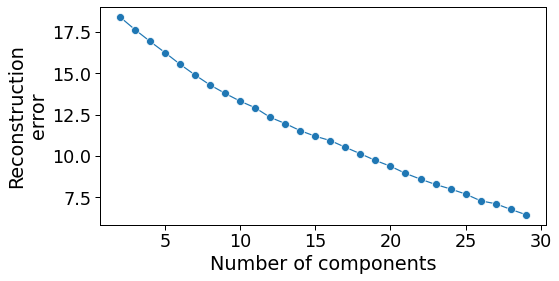

In [16]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,4))

sns.lineplot(recon_errors, x='num_k', y='error', marker='o', markersize=8, ax=ax)
ax.set_xlabel('Number of components')
ax.set_ylabel('Reconstruction\nerror')
plt.savefig(os.path.join(main_path, 'data/results/recon_errors_k2_k30.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

#### Set up NMF model with k=12

In [17]:
from sklearn.decomposition import NMF

n_components = 12
nmf = NMF(n_components=n_components, init='nndsvd', random_state=0)
W_arr = nmf.fit_transform(all_df_)
H_arr = nmf.components_

W_df = pd.DataFrame(W_arr, index=all_df['samples'], columns=[f"Component_{i+1}" for i in range(n_components)])
H_df = pd.DataFrame(H_arr, index=[f"Component_{i+1}" for i in range(n_components)], columns=all_df_.columns)

In [20]:
# H_df is the contribution of each cluster to each component
# Array of shape n_components x n_clusters, each score non-negative

# W_df is each sample's reduced dimension matrix
# Array of shape n_samples x n_components, each non-negative contribution

H_df.to_csv(os.path.join(main_path, 'data/results/H_df_k12.csv'))
W_df.to_csv(os.path.join(main_path, 'data/results/W_df_k12.csv'))

In [21]:
H_df.index = [i.replace('_', ' ') for i in H_df.index]
H_df.columns.name = 'Cluster'

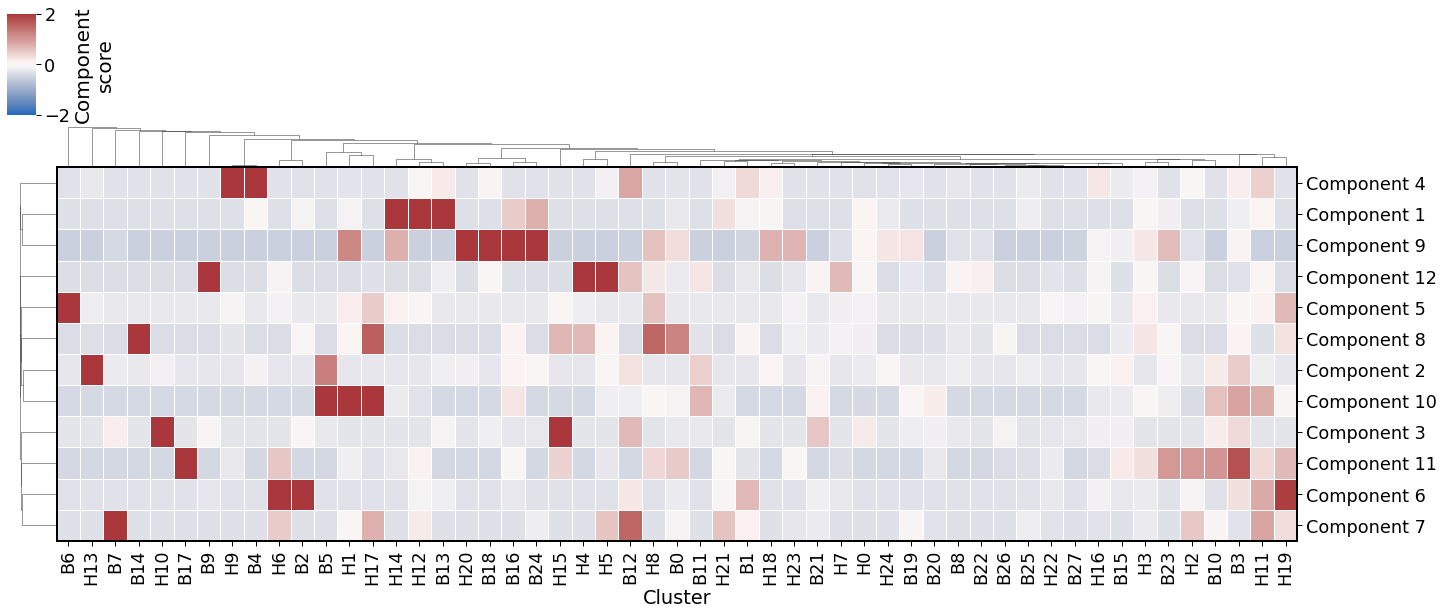

In [22]:
from matplotlib.patches import Rectangle

g = sns.clustermap(H_df, 
               cmap="vlag", 
               annot=False, 
               fmt=".2f",
               z_score=0,
               vmin=-2,
               vmax=2,
               linewidth=.5,
               dendrogram_ratio=(.03,.1),
               cbar_pos=(0, 1, 0.02, 0.2),
               figsize=(20,7))

g.ax_heatmap.collections[0].colorbar.set_label("Component\nscore", fontsize=20)
n_rows, n_cols = H_df.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)

In [23]:
W_df

,Component_1,Component_2,Component_3,Component_4,Component_5,Component_6,Component_7,Component_8,Component_9,Component_10,Component_11,Component_12
samples,,,,,,,,,,,,
ACA_1105,0.000000,0.000000,0.000000,0.143141,0.000000,0.056866,0.006732,0.000000,0.104188,0.034397,0.000000,0.051555
ACA_0937,0.058949,0.002356,0.000000,0.021119,0.000000,0.111888,0.034927,0.000000,0.138394,0.000000,0.000000,0.001516
ACA_0561,0.009981,0.000000,0.000000,0.000000,0.000000,0.291154,0.000000,0.000000,0.006975,0.012049,0.034940,0.000000
ACA_0877,0.017803,0.000000,0.040282,0.000000,0.005413,0.000000,0.034540,0.116215,0.013128,0.089797,0.001432,0.000000
ACA_0553,0.048864,0.000000,0.079178,0.120790,0.000000,0.065605,0.000000,0.006210,0.000000,0.000000,0.090802,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
ACA_0916,0.023331,0.000000,0.132747,0.000000,0.001297,0.000000,0.080604,0.050788,0.052191,0.000000,0.015210,0.011549
ACA_1040,0.000000,0.002069,0.000000,0.125010,0.000000,0.000000,0.000000,0.000000,0.231642,0.008734,0.000000,0.000574
ACA_0796,0.032816,0.000000,0.000000,0.169228,0.003271,0.009922,0.043112,0.000000,0.093257,0.029075,0.000000,0.000000


In [24]:
W_df.columns = [i.replace('_', ' ') for i in W_df.columns]
W_df.columns.name = ''

W_df.index.name = ''

Text(0.5, 68.00000000000006, 'Patients')

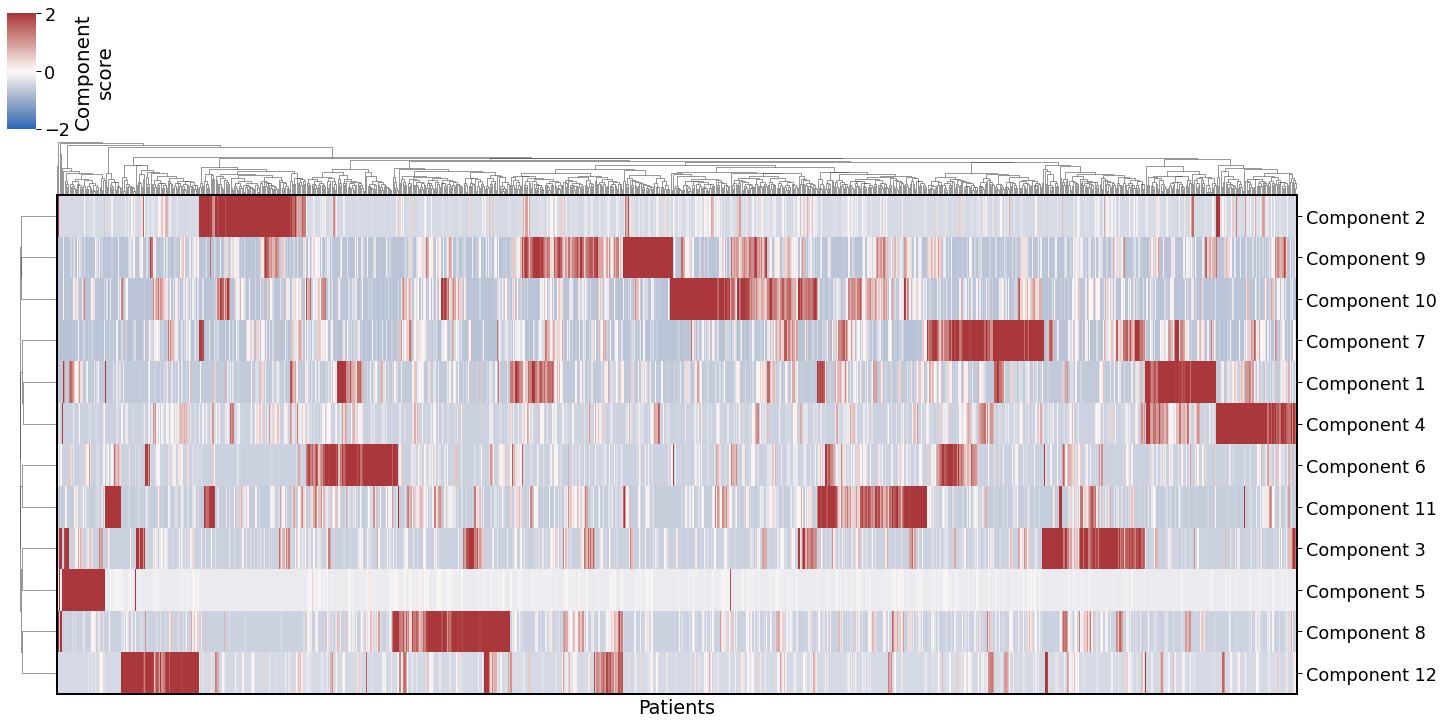

In [25]:
from matplotlib.patches import Rectangle

g = sns.clustermap(W_df.T, 
               cmap="vlag", 
               annot=False, 
            #    standard_scale=1,
            #    fmt=".2f",
               z_score=0,
               vmin=-2,
               vmax=2,
               # linewidth=.5,
               dendrogram_ratio=(.03,.1),
               cbar_pos=(0, 1, 0.02, 0.2),
               xticklabels=[],
               figsize=(20,8))

g.ax_heatmap.collections[0].colorbar.set_label("Component\nscore", fontsize=20)
n_rows, n_cols = W_df.T.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)

g.ax_heatmap.set_xlabel('Patients')

#### Associate GLB1 expression with component 6

In [26]:
import scanpy as sc

sc.pp.log1p(hallmarks_adata, base=10)
sc.pp.combat(hallmarks_adata, key='TMA')

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:401: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [27]:
hallmarks_adata.obs['samples'] = hallmarks_adata.obs['Core_ID'].map(hallmarks_core_dict)

In [28]:
hallmarks_adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,t_CellX,t_CellY,y_start,y_stop,x_start,x_stop,leiden,samples
2,17542.868552,-45460.892577,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,442.497352,-111.521377,111.3728,222.7456,334.1184,445.4912,6,ACA_0553
4,17469.690327,-45463.795477,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,369.319127,-114.424277,111.3728,222.7456,334.1184,445.4912,6,ACA_0553
5,17520.600596,-45461.630647,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,420.229396,-112.259447,111.3728,222.7456,334.1184,445.4912,6,ACA_0553
6,17485.202025,-45465.372685,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,384.830825,-116.001485,111.3728,222.7456,334.1184,445.4912,6,ACA_0553
7,17524.186586,-45469.499116,"ACA_TMA10_16-0305-2-B2_Core[1,4,D]_[17699,4714...",10,10-04-D,Tumour,423.815386,-120.127916,111.3728,222.7456,334.1184,445.4912,6,ACA_0553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15321376,10108.344216,-48179.921605,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,989.973016,-979.550405,890.9824,1002.3552,890.9824,1002.3552,1,ACA_1059
15321378,10033.132785,-48187.297909,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,914.761585,-986.926709,890.9824,1002.3552,890.9824,1002.3552,1,ACA_1059
15321379,10080.320795,-48189.404560,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,961.949595,-989.033360,890.9824,1002.3552,890.9824,1002.3552,1,ACA_1059
15321382,10084.568030,-48195.721299,"ACA_TMA22_17-424-1-B2_Core[1,5,H]_[9717,48996]...",22,22-05-H,Stroma,966.196830,-995.350099,890.9824,1002.3552,890.9824,1002.3552,1,ACA_1059


In [29]:
W_df.index.name = 'samples'

In [33]:
if os.path.isfile(os.path.join(main_path, 'data/results/per_patient_glb1_intensity_component_6.csv')):
    sample_glb1_intensity = pd.read_csv(os.path.join(main_path, 'data/results/per_patient_glb1_intensity_component_6.csv'))
else:
    sample_intensity_list = list()

    for sample in W_df.index:
        mean_intensity = np.mean(hallmarks_adata.X[(hallmarks_adata.obs['samples'] == sample) & (hallmarks_adata.obs['Region'] == 'Tumour'), hallmarks_adata.var_names == 'GLB1'])
        sample_intensity_list.append((sample, mean_intensity))
    
    sample_glb1_intensity = pd.DataFrame(sample_intensity_list, columns=['samples', 'GLB1'])
    sample_glb1_intensity = sample_glb1_intensity.merge(W_df.reset_index()[['samples', 'Component 6']], on='samples')

sample_glb1_intensity

,Unnamed: 0,samples,GLB1,Component 6
0,0,ACA_1105,0.471561,0.056866
1,1,ACA_0937,0.489256,0.111888
2,2,ACA_0561,0.561460,0.291154
3,3,ACA_0877,0.451196,0.000000
4,4,ACA_0553,0.527294,0.065605
...,...,...,...,...
990,990,ACA_0916,0.562773,0.000000
991,991,ACA_1040,0.268058,0.000000
992,992,ACA_0796,0.431402,0.009922
993,993,ACA_0060,0.259650,0.000000


Text(0, 0.5, 'Mean tumour GLB1 pixel intensity')

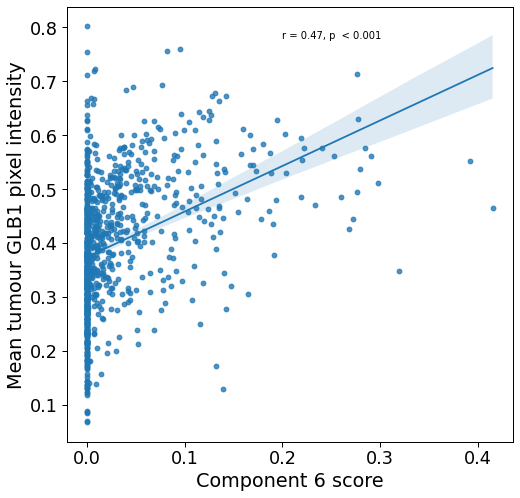

In [36]:
from scipy import stats

fig, ax = plt.subplots(figsize=(8,8))
sns.regplot(sample_glb1_intensity, x='Component 6', y='GLB1', ax=ax)
stat, p_val = stats.spearmanr(sample_glb1_intensity['Component 6'].values, sample_glb1_intensity['GLB1'].values)
# ax.text(s=f'r = {stat:.2f}, p = {p_val:.3f}', x=0.2, y=0.78)
ax.text(s=f'r = {stat:.2f}, p  < 0.001', x=0.2, y=0.78)
ax.set_xlabel('Component 6 score')
ax.set_ylabel('Mean tumour GLB1 pixel intensity')

### Growth pattern

Look at core-level growth pattern associations. 
Regenerate cluster frequency vectors at the core-level and transform these using the trained NMF model. 

In [37]:
hallmarks_train_df_core = generate_frequency_vector(complete_df=ssl_hallmarks_train.obs, matching_field='core', groupby='leiden', leiden_clusters=hallmarks_clusters, transform=False)
hallmarks_valid_df_core =  generate_frequency_vector(complete_df=ssl_hallmarks_valid.obs, matching_field='core', groupby='leiden', leiden_clusters=hallmarks_clusters, transform=False)
bioclavis_train_df_core = generate_frequency_vector(complete_df=ssl_bioclavis_train.obs, matching_field='core', groupby='leiden', leiden_clusters=bioclavis_clusters, transform=False)
bioclavis_valid_df_core =  generate_frequency_vector(complete_df=ssl_bioclavis_valid.obs, matching_field='core', groupby='leiden', leiden_clusters=bioclavis_clusters, transform=False)

hallmarks_train_df_core.columns = [f'H{cluster}' for cluster in hallmarks_clusters] + ['core']
bioclavis_train_df_core.columns = [f'B{cluster}' for cluster in bioclavis_clusters] + ['core']

hallmarks_valid_df_core.columns = [f'H{cluster}' for cluster in hallmarks_clusters] + ['core']
bioclavis_valid_df_core.columns = [f'B{cluster}' for cluster in bioclavis_clusters] + ['core']

all_train_df_core = hallmarks_train_df_core.merge(bioclavis_train_df_core, on='core')
all_valid_df_core = hallmarks_valid_df_core.merge(bioclavis_valid_df_core, on='core')

all_df_core = pd.concat([all_train_df_core, all_valid_df_core])

In [39]:
metadata = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'), index_col=0)
metadata = metadata.sort_values(by='core')
metadata

,slides,samples,core,patient_ID,PredominantPattern,Invasiveness,Polarity,Stroma,Crowding,Budding,...,rfs_event_data,os_event_ind,canc_spec_surv_ind,os_event_data,nac_status,laterality,tumour_size,egfr_status,kras_status,alk_status
2927,1-2-A_files,1-2-A_files,01-02-A,ACA_0296,Solid,Invasive,Intact,NaN,None,None,...,1301.0,0.0,0.0,1537.0,0.0,left,38.0,0.0,0.0,0.0
2965,1-2-B_files,1-2-B_files,01-02-B,ACA_0090,Acinar,Both,Intact,None,None,None,...,62.0,1.0,1.0,62.0,0.0,left,35.0,0.0,0.0,0.0
2213,1-2-C_files,1-2-C_files,01-02-C,ACA_0040,Acinar,Invasive,Intact,NaN,None,Single cells,...,247.0,1.0,1.0,381.0,0.0,left,86.0,0.0,0.0,0.0
2522,1-2-D_files,1-2-D_files,01-02-D,ACA_0008,Acinar,Invasive,Lost,NaN,Adhesive,None,...,326.0,1.0,1.0,434.0,0.0,right,45.0,0.0,0.0,0.0
1751,1-2-E_files,1-2-E_files,01-02-E,ACA_0192,Other,NaN,NaN,NaN,NaN,NaN,...,1266.0,0.0,0.0,1266.0,0.0,left,40.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,23-15-F_files,23-15-F_files,23-15-F,ACA_1093,Other,NaN,NaN,NaN,NaN,NaN,...,805.0,1.0,0.0,975.0,0.0,right,7.0,0.0,0.0,0.0
1376,23-15-G_files,23-15-G_files,23-15-G,ACA_1099,Other,NaN,NaN,NaN,NaN,NaN,...,1148.0,0.0,0.0,1148.0,0.0,right,16.0,0.0,0.0,0.0
593,23-15-H_files,23-15-H_files,23-15-H,ACA_1104,Solid,Invasive,Lost,NaN,None,None,...,479.0,1.0,0.0,956.0,0.0,left,72.0,0.0,1.0,0.0
1727,23-15-I_files,23-15-I_files,23-15-I,ACA_1108,Other,NaN,NaN,NaN,NaN,NaN,...,967.0,0.0,0.0,967.0,0.0,left,13.0,0.0,0.0,0.0


In [40]:
all_df_core['core_ID'] = all_df_core['core'].apply(lambda x: x[9:])

all_df_core_gp = all_df_core.merge(metadata[['core', 'PredominantPattern']], left_on='core_ID', right_on='core').dropna()
all_df_core_gp = all_df_core_gp[~all_df_core_gp['PredominantPattern'].isin(['Other', 'Not Enough Tissue'])]
all_df_core_gp

,H0,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,B21,B22,B23,B24,B25,B26,B27,core_ID,core_y,PredominantPattern
0,0.000000,0.000000,0.000000,0.082192,0.0,0.000000,0.657534,0.054795,0.041096,0.000000,...,0.126582,0.0,0.012658,0.000000,0.000000,0.000000,0.0,23-02-I,23-02-I,Papillary
1,0.000000,0.000000,0.032258,0.000000,0.0,0.016129,0.758065,0.000000,0.000000,0.064516,...,0.000000,0.0,0.000000,0.053333,0.000000,0.000000,0.0,19-07-I,19-07-I,Papillary
2,0.000000,0.014493,0.362319,0.000000,0.0,0.014493,0.449275,0.000000,0.000000,0.000000,...,0.000000,0.0,0.012048,0.000000,0.000000,0.012048,0.0,10-04-F,10-04-F,Acinar
3,0.253165,0.063291,0.000000,0.012658,0.0,0.000000,0.000000,0.000000,0.101266,0.000000,...,0.073171,0.0,0.000000,0.048780,0.000000,0.000000,0.0,18-09-D,18-09-D,Acinar
4,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.017544,...,0.000000,0.0,0.000000,0.027027,0.000000,0.000000,0.0,10-03-D,10-03-D,Papillary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2470,0.000000,0.028986,0.000000,0.014493,0.0,0.565217,0.000000,0.057971,0.028986,0.028986,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,10-09-I,10-09-I,Solid
2471,0.000000,0.381579,0.026316,0.026316,0.0,0.000000,0.000000,0.000000,0.105263,0.026316,...,0.000000,0.0,0.033708,0.022472,0.011236,0.000000,0.0,23-04-D,23-04-D,Papillary
2472,0.000000,0.342105,0.000000,0.039474,0.0,0.000000,0.039474,0.013158,0.026316,0.000000,...,0.013699,0.0,0.041096,0.013699,0.000000,0.000000,0.0,16-05-B,16-05-B,Acinar
2473,0.000000,0.000000,0.013699,0.041096,0.0,0.054795,0.136986,0.000000,0.301370,0.000000,...,0.000000,0.0,0.178082,0.000000,0.000000,0.000000,0.0,07-14-E,07-14-E,Acinar


In [41]:
W_core_all = nmf.transform(all_df_core_gp[[col for col in all_df_core_gp.columns if col[0] in ['H', 'B']]])
W_core_df = pd.DataFrame(W_core_all, index=all_df_core_gp.index, columns=[f"Component_{i+1}" for i in range(n_components)])
W_core_df['predom_pattern'] = all_df_core_gp['PredominantPattern']
W_core_df['core'] = all_df_core_gp['core_y'].values
W_core_df['samples'] = W_core_df['core'].map(hallmarks_core_dict)
W_core_df

,Component_1,Component_2,Component_3,Component_4,Component_5,Component_6,Component_7,Component_8,Component_9,Component_10,Component_11,Component_12,predom_pattern,core,samples
0,0.000000,0.000000,0.000000,0.000000,0.002403,0.164237,0.034136,0.003748,0.005580,0.008196,0.029683,0.152456,Papillary,23-02-I,ACA_1105
1,0.100494,0.001821,0.000000,0.050462,0.000000,0.199011,0.025426,0.000000,0.000000,0.000000,0.000000,0.011883,Papillary,19-07-I,ACA_0937
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.278729,0.000000,0.000000,0.000000,0.000000,0.118478,0.000000,Acinar,10-04-F,ACA_0561
3,0.015288,0.001422,0.086904,0.000000,0.001877,0.000000,0.047970,0.013915,0.026614,0.157279,0.000000,0.000000,Acinar,18-09-D,ACA_0877
4,0.011256,0.000000,0.260768,0.000000,0.000000,0.169812,0.000000,0.015301,0.000000,0.000000,0.000000,0.000000,Papillary,10-03-D,ACA_0553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2470,0.000000,0.006591,0.000000,0.017051,0.000000,0.001916,0.028502,0.232390,0.000000,0.008859,0.000000,0.055869,Solid,10-09-I,ACA_0576
2471,0.000000,0.000000,0.013663,0.010168,0.003589,0.000000,0.072551,0.013006,0.031661,0.150019,0.056548,0.000000,Papillary,23-04-D,ACA_1082
2472,0.000000,0.005973,0.000000,0.000000,0.003391,0.042311,0.000000,0.000000,0.008356,0.279652,0.025795,0.000000,Acinar,16-05-B,ACA_0788
2473,0.000000,0.000000,0.000000,0.000000,0.003911,0.023309,0.012010,0.255011,0.009329,0.000000,0.021117,0.000000,Acinar,07-14-E,ACA_0414


In [42]:
W_core_df.to_csv(os.path.join(main_path, 'data/results/W_df_k12_core.csv'))

In [43]:
from scipy import stats

def enrichment_test_by_phenotype(data, phenotype_cols, meta_col, p_th=0.05):
    results = list()
    overall_avg = data.mean(numeric_only=True, axis=0)
    for group in data[meta_col].unique():
        for phenotype in phenotype_cols:
            positive_group = data[data[meta_col] == group][phenotype].values
            # negative_group = data[data[meta_col] != group][phenotype].values
            negative_group = data[phenotype].values
            statistic, p_value = stats.mannwhitneyu(positive_group, negative_group, alternative='two-sided')
            # relative_change = (np.mean(positive_group) - np.mean(negative_group)) / (abs(np.mean(negative_group)) + 0.001)
            # relative_change = (np.mean(positive_group) - np.mean(negative_group)) / (abs(np.mean(negative_group)) + 0.001)
            log_fc = np.log2((np.mean(positive_group) + 1e-9) / (overall_avg.loc[phenotype] + 1e-9))


            results.append({
                'Supercluster':group,
                'marker':phenotype,
                'l2fc':log_fc,
                'statistic':statistic,
                'p_val': p_value
            })

    results = pd.DataFrame(results)
    results['p_adj'] = stats.false_discovery_control(results['p_val'], method='bh')
    change_data = results.pivot(index='Supercluster', columns='marker', values='l2fc')
    pval_data = results.pivot(index='Supercluster', columns='marker', values='p_adj')

    significant_mask = pval_data < p_th
    # annot_text = pval_data.applymap('{:.3f}'.format)
    annot_text = change_data.applymap('{:.2f}'.format)
    annot_text = annot_text.mask(significant_mask, '*')
    annot_text = annot_text.mask(~significant_mask, ' ')

    return change_data, annot_text

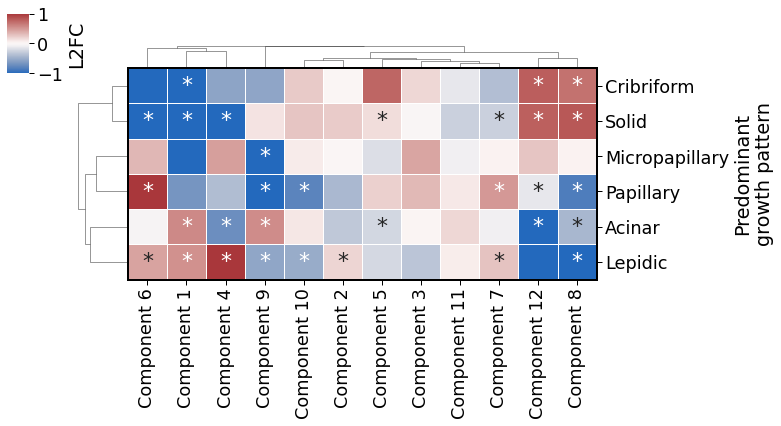

In [44]:
change_data, annot_text = enrichment_test_by_phenotype(W_core_df, phenotype_cols=[f'Component_{i}' for i in range(1, 13, 1)], meta_col='predom_pattern', p_th=0.01)

change_data.index.name = 'Predominant\ngrowth pattern'
change_data.columns.name = ''

change_data.columns = [c.replace('_', ' ') for c in change_data.columns]

g = sns.clustermap(change_data,
               cmap='vlag',
               linewidth=.5,
               vmin=-1, vmax=1,
               annot=annot_text,
               fmt='',
               annot_kws={'fontsize':22},
               row_cluster=True,
               dendrogram_ratio=(.1, .1), 
               cbar_pos=(-0.08, 0.9, 0.03, 0.15), 
               cbar_kws={'label': 'L2FC'},
               figsize=(10,5.5))

n_rows, n_cols = change_data.shape
g.ax_heatmap.collections[0].set_linewidth(.5)

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)

In [42]:
W_core_df['predom_pattern'].value_counts()

Acinar            707
Solid             678
Lepidic           484
Papillary         181
Cribriform        119
Micropapillary    115
Name: predom_pattern, dtype: int64

/tmp/ipykernel_3729281/2055191570.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0, 0.5, 'Component 6 score')

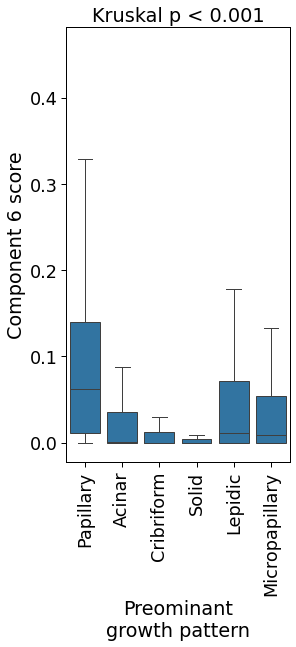

In [45]:
gp_comp_6 = list()

for gp in W_core_df['predom_pattern'].unique():
    val = W_core_df[W_core_df['predom_pattern'] == gp]['Component_6']
    gp_comp_6.append(val)

stat, p_val = stats.kruskal(*gp_comp_6)

fig, ax = plt.subplots(figsize=(4,8))
sns.boxplot(W_core_df, x = 'predom_pattern', y = 'Component_6', fliersize=0., ax=ax)
# sns.stripplot(W_core_df, x = 'predom_pattern', y = 'Component_6', ax=ax)
ax.set_title(f'Kruskal p < 0.001')
# fig.autofmt_xdate()
ax.set_xlabel('Preominant\ngrowth pattern')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel('Component 6 score')

### Survival associations

#### Load data

In [ ]:
clinpath, survival, patterns = load_clinical(main_path=main_path)

clinpath_mo = clinpath.rename(columns={'Time to Survival Status (Days)':'os_event_data',
                                        'Survival Status':'os_event_ind',
                                        'Age at Surgery':'age',
                                        'Sex':'male',
                                        'Overall Stage (8th TNM Edition)':'stage',
                                        })
clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
clinpath_mo = clinpath_mo.replace({'IA1': 'I', 'IA2':'I', 'IA3':'I', 'IB':'I', 
                                'IIA': 'II', 'IIB':'II',
                                'IIIA':'III', 'IIIB':'III', 'IIIC':'III', 
                                'IVA':'IV'})

clinpath_mo['stage_num'] = clinpath_mo['stage'].map({'I':1, 'II':2, 'III':3, 'IV':3})
clinpath_mo['stage_num'] = pd.Categorical(clinpath_mo['stage_num'], categories=[1, 2, 3], ordered=True)

clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})
clinpath_mo['os_event_data'] = clinpath_mo['os_event_data'] / 365 * 12

non_mucinous_samples = clinpath_mo[~clinpath_mo['2015 WHO Classification'].isin(['Invasive mucinous adenocarcinoma (IMA)', 'Colloid adenocarcinoma', 'Enteric adenocarcinoma', 'Not given'])]['samples']
clinpath_mo = clinpath_mo[clinpath_mo['samples'].isin(non_mucinous_samples)]

W_df_survival = W_df.reset_index().merge(clinpath_mo[['samples', 'os_event_ind', 'os_event_data']], on='samples', how='inner').dropna()
W_df_survival = W_df_survival.merge(patterns[['samples', 'iaslc_grade']], on='samples')
W_df_survival = pd.get_dummies(W_df_survival, prefix='G', prefix_sep='', columns=['iaslc_grade'])

/mnt/cephfs/sharedscratch/users/krakovic/MultiplexSSL/analysis/libraries/clinical.py:7: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv('/mnt/cephfs/home/users/krakovic/sharedscratch/datasets/LATTICeA/latticea_master_clinicopathological.csv')


In [45]:
# W_df_survival.to_csv('/nfs/home/users/krakovic/sharedscratch/notebooks/lucas_ssl_mif/nmf_250603/W_df_k12_survival.csv')

#### Survival model

In [47]:
cph = CoxPHFitter(penalizer=0., l1_ratio=0.)
cph.fit(W_df_survival[list(W_df.columns)[:-1]+['os_event_ind', 'os_event_data']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 906 total observations, 274 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 906
number of events observed = 632
   partial log-likelihood = -3810.92
         time fit was run = 2025-10-13 12:16:07 UTC

---
               coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                            
Component 1   -0.81       0.45       1.23            -3.22             1.60                 0.04                 4.94
Component 2   -0.18       0.84       0.73            -1.61             1.25                 0.20                 3.50
Component 3    0.20       1.22       0.77            -1.31             1.71                 0.27                 5.53
Component 4   -1.49       0.22       0.85            -3.16             0.18                 0.04                 1.19
Component 5   -0.50       0.61       0.71            -1.89             0.89                 0.15                 2.44
Component 6   -2.20       0.11       0.99            -4.14            -0.25                 0.02                 0.78
Component 7   -0.48       0.62       0.74            -1.93             0.97                 0.15                 2.63
Component 8   -0.23       0.79       1.00            -2.19             1.73                 0.11                 5.65
Component 9   -0.11       0.90       0.90            -1.87             1.65                 0.15                 5.21
Component 10  -0.50       0.61       0.92            -2.29             1.30                 0.10                 3.67
Component 11  -3.00       0.05       0.93            -4.82            -1.18                 0.01                 0.31

               cmp to     z      p   -log2(p)
covariate                                    
Component 1      0.00 -0.66   0.51       0.97
Component 2      0.00 -0.24   0.81       0.31
Component 3      0.00  0.26   0.79       0.34
Component 4      0.00 -1.75   0.08       3.65
Component 5      0.00 -0.71   0.48       1.06
Component 6      0.00 -2.21   0.03       5.22
Component 7      0.00 -0.65   0.51       0.96
Component 8      0.00 -0.23   0.82       0.29
Component 9      0.00 -0.12   0.90       0.15
Component 10     0.00 -0.54   0.59       0.76
Component 11     0.00 -3.23 <0.005       9.65
---
Concordance = 0.58
Partial AIC = 7643.84
log-likelihood ratio test = 23.14 on 11 df
-log2(p) of ll-ratio test = 5.89

Text(0.5, 1.0, 'Using component scores only')

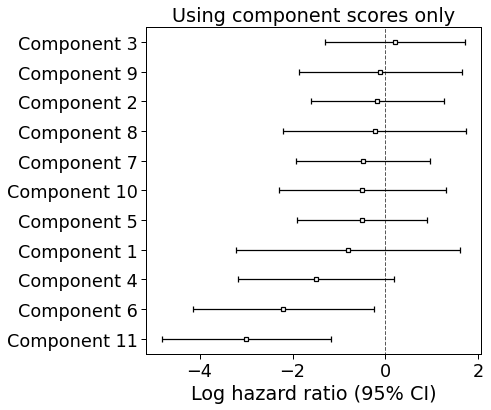

In [48]:
fig, ax = plt.subplots(figsize=(6,6))

cph.plot(ax=ax)
ax.set_xlabel('Log hazard ratio (95% CI)')
ax.set_title('Using component scores only')

In [49]:
cph = CoxPHFitter(penalizer=0., l1_ratio=0.)
cph.fit(W_df_survival[list(W_df.columns)[:-1]+['G2', 'G3', 'os_event_ind', 'os_event_data']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 906 total observations, 274 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 906
number of events observed = 632
   partial log-likelihood = -3796.32
         time fit was run = 2025-10-13 12:16:51 UTC

---
               coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                            
Component 1   -0.01       0.99       1.23            -2.41             2.40                 0.09                11.00
Component 2    0.13       1.13       0.72            -1.29             1.54                 0.28                 4.67
Component 3    0.48       1.61       0.78            -1.05             2.01                 0.35                 7.47
Component 4   -0.73       0.48       0.87            -2.43             0.97                 0.09                 2.65
Component 5   -0.13       0.88       0.71            -1.51             1.26                 0.22                 3.53
Component 6   -1.07       0.34       0.99            -3.01             0.86                 0.05                 2.37
Component 7    0.10       1.11       0.74            -1.34             1.55                 0.26                 4.72
Component 8   -0.94       0.39       1.02            -2.95             1.07                 0.05                 2.90
Component 9    0.07       1.07       0.90            -1.69             1.82                 0.18                 6.19
Component 10  -0.50       0.61       0.91            -2.28             1.29                 0.10                 3.61
Component 11  -2.41       0.09       0.92            -4.21            -0.61                 0.01                 0.55
G2             0.36       1.43       0.16             0.04             0.68                 1.04                 1.98
G3             0.72       2.06       0.16             0.40             1.04                 1.50                 2.82

               cmp to     z      p   -log2(p)
covariate                                    
Component 1      0.00 -0.00   1.00       0.01
Component 2      0.00  0.17   0.86       0.21
Component 3      0.00  0.61   0.54       0.89
Component 4      0.00 -0.84   0.40       1.32
Component 5      0.00 -0.18   0.86       0.22
Component 6      0.00 -1.08   0.28       1.85
Component 7      0.00  0.14   0.89       0.17
Component 8      0.00 -0.92   0.36       1.48
Component 9      0.00  0.07   0.94       0.09
Component 10     0.00 -0.55   0.58       0.78
Component 11     0.00 -2.62   0.01       6.83
G2               0.00  2.18   0.03       5.09
G3               0.00  4.47 <0.005      16.98
---
Concordance = 0.61
Partial AIC = 7618.63
log-likelihood ratio test = 52.34 on 13 df
-log2(p) of ll-ratio test = 19.70

[Text(0, 0, 'Component 11'),
 Text(0, 1, 'Component 6'),
 Text(0, 2, 'Component 8'),
 Text(0, 3, 'Component 4'),
 Text(0, 4, 'Component 10'),
 Text(0, 5, 'Component 5'),
 Text(0, 6, 'Component 1'),
 Text(0, 7, 'Component 9'),
 Text(0, 8, 'Component 7'),
 Text(0, 9, 'Component 2'),
 Text(0, 10, 'IASLC G2'),
 Text(0, 11, 'Component 3'),
 Text(0, 12, 'IASLC G3')]

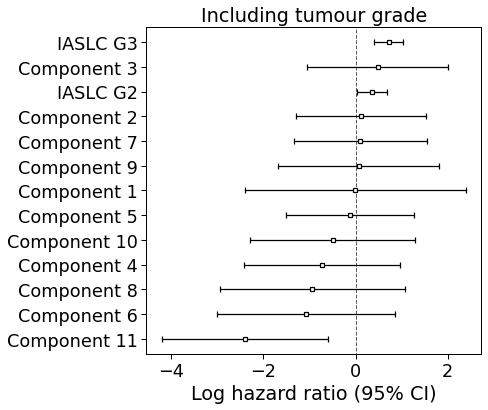

In [50]:
fig, ax = plt.subplots(figsize=(6,6))

cph.plot(ax=ax)
ax.set_xlabel('Log hazard ratio (95% CI)')
ax.set_title('Including tumour grade')
yticks = ax.get_yticklabels()
yticks[-1] = 'IASLC G3'
yticks[-3] = 'IASLC G2'
ax.set_yticklabels(yticks)

If adding in grade, component 6 falls further into statistical insignificance but is still a negative coef \
Component 11 remains good prognosis

#### Sub-group analysis: low grade tumours

In [51]:
W_df_survival_LG = W_df_survival[W_df_survival['G3'] != 1]

cph = CoxPHFitter(penalizer=0., l1_ratio=0.)
cph.fit(W_df_survival_LG[list(W_df.columns)[:-1]+['os_event_ind', 'os_event_data']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 384 total observations, 147 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 384
number of events observed = 237
   partial log-likelihood = -1218.17
         time fit was run = 2025-10-13 12:22:49 UTC

---
               coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                            
Component 1    3.38      29.37       2.25            -1.03             7.79                 0.36              2412.91
Component 2    0.93       2.54       1.50            -2.00             3.87                 0.14                47.79
Component 3    0.25       1.29       1.57            -2.82             3.33                 0.06                28.00
Component 4   -0.65       0.52       1.56            -3.70             2.41                 0.02                11.11
Component 5    1.74       5.69       1.24            -0.69             4.17                 0.50                64.42
Component 6    1.80       6.07       1.69            -1.52             5.12                 0.22               167.75
Component 7    0.62       1.85       1.47            -2.26             3.49                 0.10                32.71
Component 8    5.66     288.19       2.35             1.05            10.28                 2.86             29048.50
Component 9    0.27       1.31       1.94            -3.52             4.06                 0.03                58.16
Component 10   1.95       7.05       2.10            -2.17             6.08                 0.11               435.67
Component 11  -2.00       0.13       1.88            -5.68             1.67                 0.00                 5.32

               cmp to     z    p   -log2(p)
covariate                                  
Component 1      0.00  1.50 0.13       2.91
Component 2      0.00  0.62 0.53       0.91
Component 3      0.00  0.16 0.87       0.20
Component 4      0.00 -0.42 0.68       0.56
Component 5      0.00  1.40 0.16       2.64
Component 6      0.00  1.06 0.29       1.80
Component 7      0.00  0.42 0.67       0.57
Component 8      0.00  2.41 0.02       5.96
Component 9      0.00  0.14 0.89       0.17
Component 10     0.00  0.93 0.35       1.50
Component 11     0.00 -1.07 0.29       1.81
---
Concordance = 0.59
Partial AIC = 2458.34
log-likelihood ratio test = 19.12 on 11 df
-log2(p) of ll-ratio test = 4.08

<Axes: xlabel='log(HR) (95% CI)'>

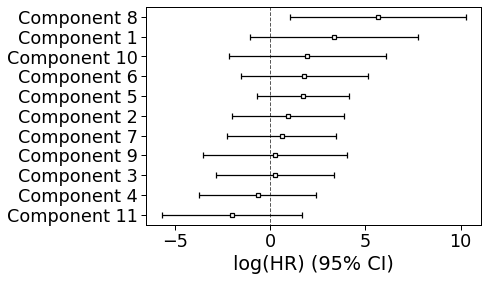

In [52]:
cph.plot()

#### Sub-group analysis: high grade tumours

In [53]:
W_df_survival_HG = W_df_survival[W_df_survival['G3'] == 1]

cph = CoxPHFitter(penalizer=0., l1_ratio=0.)
cph.fit(W_df_survival_HG[list(W_df.columns)[:-1]+['os_event_ind', 'os_event_data']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 522 total observations, 127 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 522
number of events observed = 395
   partial log-likelihood = -2158.27
         time fit was run = 2025-10-13 12:22:54 UTC

---
               coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                            
Component 1   -1.75       0.17       1.69            -5.07             1.57                 0.01                 4.80
Component 2    0.08       1.08       0.83            -1.55             1.71                 0.21                 5.53
Component 3    0.66       1.93       0.93            -1.17             2.48                 0.31                11.97
Component 4   -0.06       0.94       1.19            -2.39             2.27                 0.09                 9.63
Component 5   -0.91       0.40       1.00            -2.87             1.05                 0.06                 2.85
Component 6   -4.34       0.01       1.69            -7.65            -1.03                 0.00                 0.36
Component 7    0.38       1.46       0.92            -1.43             2.19                 0.24                 8.97
Component 8   -1.61       0.20       1.14            -3.83             0.62                 0.02                 1.86
Component 9    0.51       1.67       1.03            -1.51             2.54                 0.22                12.64
Component 10  -0.90       0.41       1.02            -2.91             1.10                 0.05                 3.00
Component 11  -2.16       0.11       1.09            -4.31            -0.02                 0.01                 0.98

               cmp to     z    p   -log2(p)
covariate                                  
Component 1      0.00 -1.03 0.30       1.73
Component 2      0.00  0.10 0.92       0.11
Component 3      0.00  0.71 0.48       1.06
Component 4      0.00 -0.05 0.96       0.06
Component 5      0.00 -0.91 0.36       1.47
Component 6      0.00 -2.57 0.01       6.63
Component 7      0.00  0.41 0.68       0.56
Component 8      0.00 -1.42 0.16       2.67
Component 9      0.00  0.50 0.62       0.69
Component 10     0.00 -0.88 0.38       1.41
Component 11     0.00 -1.98 0.05       4.39
---
Concordance = 0.59
Partial AIC = 4338.55
log-likelihood ratio test = 23.01 on 11 df
-log2(p) of ll-ratio test = 5.83

<Axes: xlabel='log(HR) (95% CI)'>

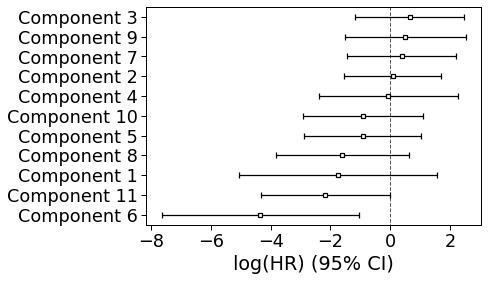

In [54]:
cph.plot()

#### Kaplan Meiers

In [55]:
# The all cutoff is the same as the high grade one
# Probably influenced by the high proportion of high grade cases in the cohort

survminer_cutoff_all = 0.01082824
survminer_cutoff_lg = 0.05260054
survminer_cutoff_hg = 0.01082824

W_df_survival_LG['comp_6_high'] = W_df_survival_LG['Component 6'].apply(lambda x: 1 if x > survminer_cutoff_all else 0)
W_df_survival_HG['comp_6_high'] = W_df_survival_HG['Component 6'].apply(lambda x: 1 if x > survminer_cutoff_all else 0)
W_df_survival['comp_6_high'] = W_df_survival['Component 6'].apply(lambda x: 1 if x > survminer_cutoff_all else 0)


/tmp/ipykernel_3729281/2066417765.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  W_df_survival_LG['comp_6_high'] = W_df_survival_LG['Component 6'].apply(lambda x: 1 if x > survminer_cutoff_all else 0)
/tmp/ipykernel_3729281/2066417765.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  W_df_survival_HG['comp_6_high'] = W_df_survival_HG['Component 6'].apply(lambda x: 1 if x > survminer_cutoff_all else 0)


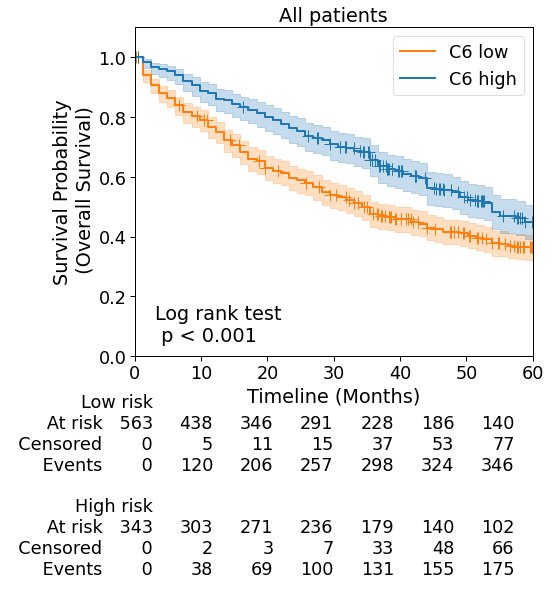

In [57]:
from analysis.libraries.survival import plot_km_two_groups 

sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=W_df_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='All patients', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

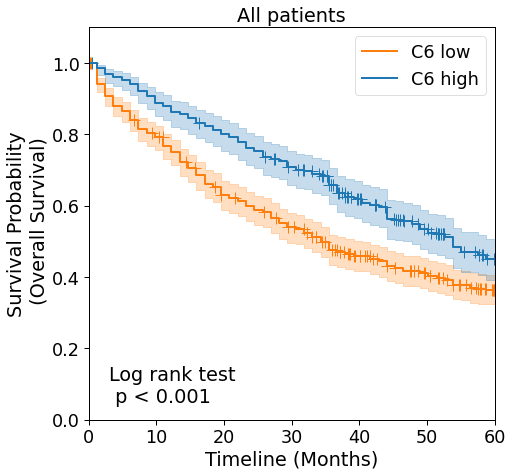

In [58]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=W_df_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='All patients', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

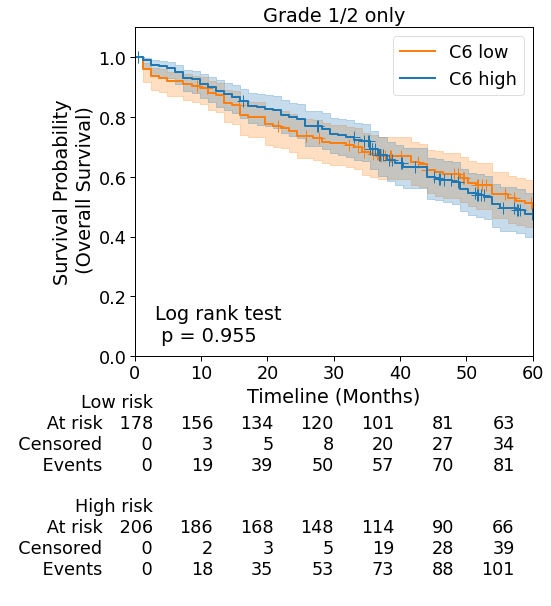

In [59]:
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=W_df_survival_LG.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='Grade 1/2 only', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

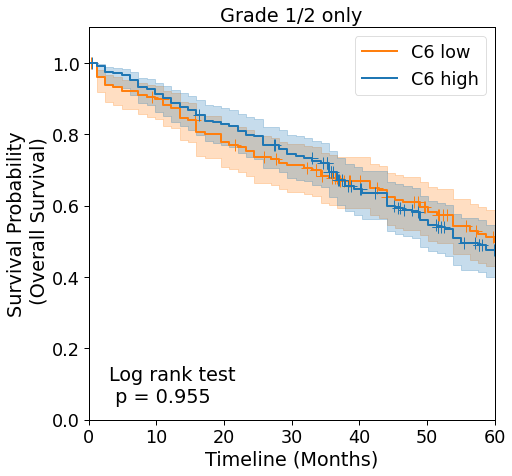

In [60]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=W_df_survival_LG.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Grade 1/2 only', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

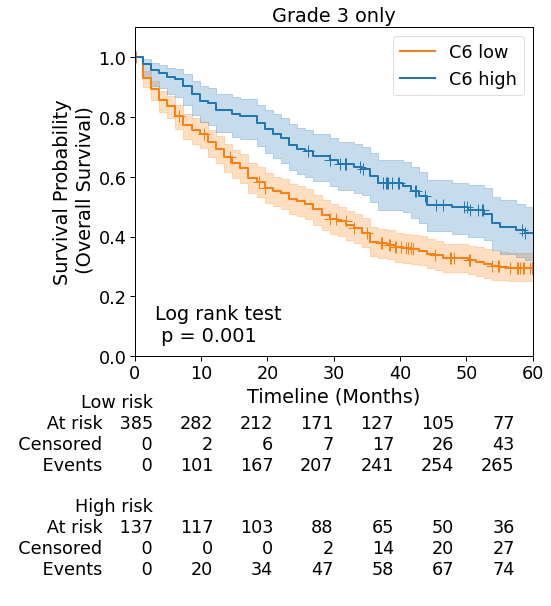

In [61]:
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=W_df_survival_HG.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='Grade 3 only', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

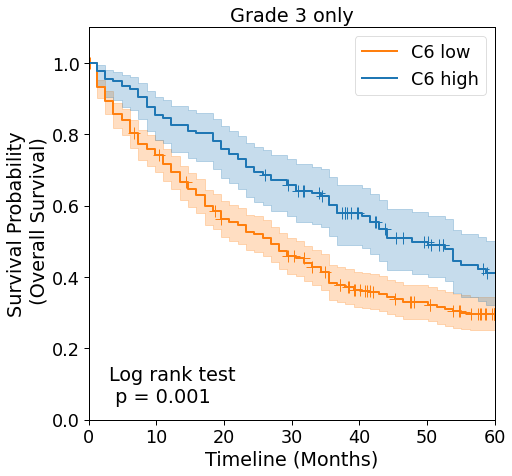

In [62]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=W_df_survival_HG.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='comp_6_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Grade 3 only', 
                   ci_show=True, 
                   ax=ax)

handles, labels = ax.get_legend_handles_labels()
labels = ['C6 low', 'C6 high']
ax.legend(handles, labels)

### Genotype

#### Load data

In [63]:
genetics = pd.read_csv(os.path.join(main_path, 'data/metadata/LatticeDatabase_withgenetics.tsv'), sep='\t')

genetics = genetics.sort_values(by='case_num').reset_index()
genetics['case_num'] = genetics['case_num'].astype(str)

samples_list = []

for i in range(1, 5):
    indexes = genetics[genetics['case_num'].str.len() == i].index
    if i == 1:
        samples_list.extend(['ACA_000' + str(x) for x in genetics.iloc[indexes]['case_num']])
    elif i == 2:
        samples_list.extend(['ACA_00' + str(x) for x in genetics.iloc[indexes]['case_num']])
    elif i == 3:
        samples_list.extend(['ACA_0' + str(x) for x in genetics.iloc[indexes]['case_num']])
    else:
        samples_list.extend(['ACA_' + str(x) for x in genetics.iloc[indexes]['case_num']])

genetics['samples'] = samples_list

genetics = genetics.replace({'negative':0, 'positive':1})

genetics

,index,case_num,OS_time,OS_status,CSS_time,CSS_status,RFS_time,RFS_status,chemo_status,age,...,KIT,NRAS,MAP2K1,FBXW7,SMARCA4,HRAS,PDGFRA,suppressor,driver,samples
0,159,2,570,0,570.00,0,520.00,0,no,76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,ACA_0002
1,238,3,1743,1,1095.75,0,210.00,0,no,77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TP53,EGFR,ACA_0003
2,319,4,1070,1,1070.00,1,1070.00,1,no,61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,ACA_0004
3,406,5,1865,0,1095.75,0,1095.75,0,no,64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,ACA_0005
4,499,6,17,1,17.00,0,17.00,0,no,81,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACA_0006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,101,1108,967,0,967.00,0,967.00,0,no,61,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,EGFR,ACA_1108
875,102,1109,630,1,630.00,0,475.00,1,no,83,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,none,ACA_1109
876,103,1110,669,1,669.00,0,560.00,1,yes,71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TP53,KRAS,ACA_1110
877,104,1112,743,1,743.00,0,711.00,0,no,65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TP53,other,ACA_1112


In [64]:
W_df_genetics = W_df.merge(genetics[['samples', 'EGFR', 'KRAS', 'TP53', 'BRAF']], on='samples')
# W_df_genetics = W_df.merge(genetics[['samples', 'driver', 'suppressor', 'EGFR', 'KRAS', 'TP53', 'BRAF']], on='samples')

# W_df_genetics['driver'] = W_df_genetics['driver'].replace({'none':'unknown',
#                                                            'other':'unknown',
#                                                            'KRAS plus other':'KRAS',
#                                                            'EGFR plus other':'EGFR'}).fillna('unknown')


W_df_genetics

,samples,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,Component 11,Component 12,EGFR,KRAS,TP53,BRAF
0,ACA_1105,0.000000,0.000000,0.000000,0.143141,0.000000,0.056866,0.006732,0.000000,0.104188,0.034397,0.000000,0.051555,0.0,1.0,0.0,0.0
1,ACA_0937,0.058949,0.002356,0.000000,0.021119,0.000000,0.111888,0.034927,0.000000,0.138394,0.000000,0.000000,0.001516,0.0,0.0,0.0,1.0
2,ACA_0561,0.009981,0.000000,0.000000,0.000000,0.000000,0.291154,0.000000,0.000000,0.006975,0.012049,0.034940,0.000000,0.0,1.0,1.0,0.0
3,ACA_0877,0.017803,0.000000,0.040282,0.000000,0.005413,0.000000,0.034540,0.116215,0.013128,0.089797,0.001432,0.000000,NaN,NaN,NaN,NaN
4,ACA_0553,0.048864,0.000000,0.079178,0.120790,0.000000,0.065605,0.000000,0.006210,0.000000,0.000000,0.090802,0.000000,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,ACA_0916,0.023331,0.000000,0.132747,0.000000,0.001297,0.000000,0.080604,0.050788,0.052191,0.000000,0.015210,0.011549,0.0,0.0,0.0,0.0
846,ACA_1040,0.000000,0.002069,0.000000,0.125010,0.000000,0.000000,0.000000,0.000000,0.231642,0.008734,0.000000,0.000574,0.0,0.0,0.0,0.0
847,ACA_0796,0.032816,0.000000,0.000000,0.169228,0.003271,0.009922,0.043112,0.000000,0.093257,0.029075,0.000000,0.000000,0.0,1.0,1.0,0.0
848,ACA_0060,0.000000,0.212698,0.000000,0.198683,0.000000,0.000000,0.000000,0.000000,0.113365,0.000000,0.000000,0.000000,0.0,1.0,1.0,0.0


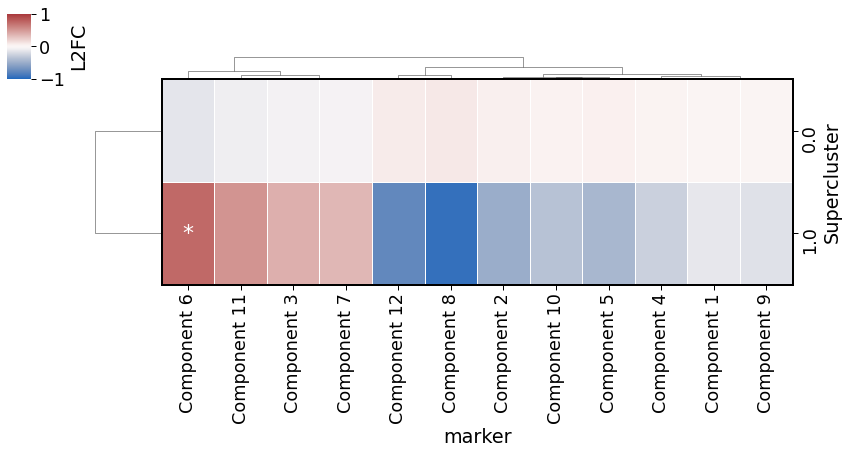

In [65]:
change_data, annot_text = enrichment_test_by_phenotype(W_df_genetics.dropna(subset='EGFR'), phenotype_cols=[f'Component {i}' for i in range(1, 13, 1)], meta_col='EGFR')

g = sns.clustermap(change_data,
               cmap='vlag',
               linewidth=.5,
               vmin=-1, vmax=1,
               annot=annot_text,
               fmt='',
               annot_kws={'fontsize':22},
               row_cluster=True,
               dendrogram_ratio=(.1, .1), 
               cbar_pos=(-0.08, 0.9, 0.03, 0.15), 
               cbar_kws={'label': 'L2FC'},
               figsize=(11,6))

n_rows, n_cols = change_data.shape
g.ax_heatmap.collections[0].set_linewidth(.5)

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
# g.cax.tick_params(labelrotation=90)

/tmp/ipykernel_3729281/3327681138.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['WT', 'Mutant'])


[Text(0, 0, 'WT'), Text(1, 0, 'Mutant')]

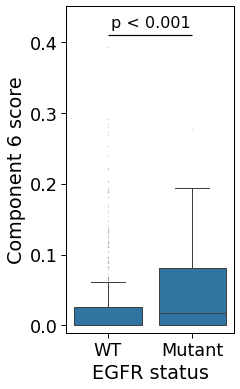

In [66]:
fig, ax = plt.subplots(figsize=(3,6))

sns.boxplot(W_df_genetics, x='EGFR', y='Component 6', fliersize=.1, ax=ax)
stat, p_val = stats.mannwhitneyu(W_df_genetics[W_df_genetics['EGFR'] == 1]['Component 6'].values, W_df_genetics[W_df_genetics['EGFR'] == 0]['Component 6'].values, alternative='two-sided')
ax.set_ylim([-0.01, 0.45])
ax.hlines(xmin=0, xmax=1, y=0.41, color='black')
ax.text(s=f'p < 0.001', x=0.04, y=0.42, fontsize=16)
# ax.text(s=f'p = {p_val:.3f}', x=0.04, y=0.42, fontsize=16)
ax.set_ylabel('Component 6 score')
ax.set_xlabel('EGFR status')
ax.set_xticklabels(['WT', 'Mutant'])

In [67]:
W_df_genetics['EGFR'].value_counts()

0.0    559
1.0     79
Name: EGFR, dtype: int64

### Clinical associations

#### Smoking history

In [68]:
W_df_smoking = W_df_survival.merge(clinpath_mo[['samples', 'Smoking History', 'Pack Years']], on='samples')
W_df_smoking

,samples,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,...,Component 11,Component 12,os_event_ind,os_event_data,G1,G2,G3,comp_6_high,Smoking History,Pack Years
0,ACA_1105,0.000000,0.000000,0.000000,0.143141,0.000000,0.056866,0.006732,0.000000,0.104188,...,0.000000,0.051555,1,25.610959,0,1,0,1,ex-smoker,20.0
1,ACA_0937,0.058949,0.002356,0.000000,0.021119,0.000000,0.111888,0.034927,0.000000,0.138394,...,0.000000,0.001516,1,43.068493,0,1,0,1,ex-smoker,15.0
2,ACA_0561,0.009981,0.000000,0.000000,0.000000,0.000000,0.291154,0.000000,0.000000,0.006975,...,0.034940,0.000000,0,90.213699,0,0,1,1,ex-smoker,45.0
3,ACA_0877,0.017803,0.000000,0.040282,0.000000,0.005413,0.000000,0.034540,0.116215,0.013128,...,0.001432,0.000000,1,23.671233,0,1,0,0,current,NaN
4,ACA_0553,0.048864,0.000000,0.079178,0.120790,0.000000,0.065605,0.000000,0.006210,0.000000,...,0.090802,0.000000,0,99.287671,0,1,0,1,current,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,ACA_0916,0.023331,0.000000,0.132747,0.000000,0.001297,0.000000,0.080604,0.050788,0.052191,...,0.015210,0.011549,0,103.824658,0,1,0,0,ex-smoker,30.0
902,ACA_1040,0.000000,0.002069,0.000000,0.125010,0.000000,0.000000,0.000000,0.000000,0.231642,...,0.000000,0.000574,1,5.523288,0,0,1,0,not known,NaN
903,ACA_0796,0.032816,0.000000,0.000000,0.169228,0.003271,0.009922,0.043112,0.000000,0.093257,...,0.000000,0.000000,1,0.295890,0,0,1,0,current,41.0
904,ACA_0060,0.000000,0.212698,0.000000,0.198683,0.000000,0.000000,0.000000,0.000000,0.113365,...,0.000000,0.000000,1,38.498630,0,0,1,0,current,45.0


In [69]:
W_df_smoking['Smoking History'] = W_df_smoking['Smoking History'].replace({'ex-smoker':'smoker', 'current':'smoker'})
W_df_smoking = W_df_smoking[W_df_smoking['Smoking History'] != 'not known']

In [70]:
W_df_smoking['Smoking History'].value_counts()

smoker          736
never smoked     65
Name: Smoking History, dtype: int64

/tmp/ipykernel_3729281/3669082959.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current or\nprevious', 'Never\nsmoked'], rotation=90)


[Text(0, 0, 'Current or\nprevious'), Text(1, 0, 'Never\nsmoked')]

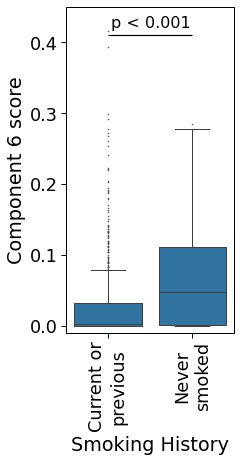

In [71]:
fig, ax = plt.subplots(figsize=(3,6))

sns.boxplot(W_df_smoking, x='Smoking History', y='Component 6', fliersize=.5, ax=ax)
stat, p_val = stats.mannwhitneyu(W_df_smoking[W_df_smoking['Smoking History'] == 'smoker']['Component 6'].values, W_df_smoking[W_df_smoking['Smoking History'] != 'smoker']['Component 6'].values, alternative='two-sided')
ax.set_ylim([-0.01, 0.45])
ax.hlines(xmin=0, xmax=1, y=0.41, color='black')
ax.text(s=f'p < 0.001', x=0.04, y=0.42, fontsize=16)
# ax.text(s=f'p = {p_val:.3f}', x=0.04, y=0.42, fontsize=16)
ax.set_ylabel('Component 6 score')
ax.set_xticklabels(['Current or\nprevious', 'Never\nsmoked'], rotation=90)


<Axes: >

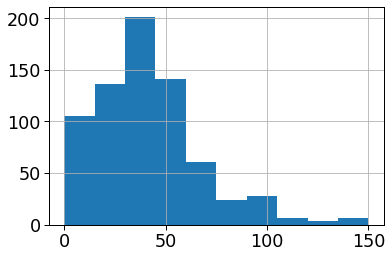

In [ ]:
W_df_smoking['Pack Years'].hist()

Text(0.5, 1.0, 'All patients')

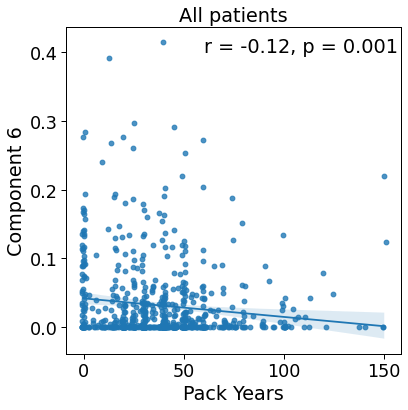

In [74]:
fig, ax = plt.subplots(figsize=(6,6))
stat, p_val = stats.spearmanr(W_df_smoking['Component 6'].values, W_df_smoking['Pack Years'].values, nan_policy='omit')
ax.text(s=f'r = {stat:.2f}, p = {p_val:.3f}', x=60, y=0.4)
ax.set_ylabel('Component 6 score')
ax.set_xlabel('Smoking history (pack years)')
sns.regplot(W_df_smoking, x='Pack Years', y='Component 6', x_jitter=True, ax=ax)
ax.set_title('All patients')

In [79]:
fig, ax = plt.subplots(figsize=(6,6))
smokers_only = W_df_smoking[W_df_smoking['Smoking History'].isin(['current', 'ex-smoker'])]
stat, p_val = stats.spearmanr(smokers_only['Component 6'].values, smokers_only['Pack Years'].values, nan_policy='omit')
ax.text(s=f'r = {stat:.2f}, p = {p_val:.3f}', x=60, y=0.4)
ax.set_ylabel('Component 6 score')
ax.set_xlabel('Smoking history (pack years)')
sns.regplot(smokers_only, x='Pack Years', y='Component 6', x_jitter=True, ax=ax)
ax.set_title('Current and ex-smokers')

Text(0.5, 1.0, 'Current and ex-smokers')

ValueError: Image size of 183046x1427 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 432x432 with 1 Axes>